In [44]:
import os
import sys
import plotly.graph_objects as go

import matplotlib.pyplot as plt
current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)
from src.models.filter_data.filter_data import *
from src.models.filter_data.feature_adder import *

In [45]:
l_min = 4
max_diff = 3
c_thresh = 0.9

csv_read_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")

df = pd.read_csv(csv_read_path, encoding='utf-8')
df.loc[df["is_good_peak"]>=4,"is_good_peak"] = 4
df_c = df

In [46]:
import plotly.express as px
def show(df_m1,save=False,param=None,ass=""):

    fig = px.scatter(df_m1, x="datetime", y='generation', color='is_good_peak',
                    title='Generation over Time by Batch Interval',
                    labels={'generation': 'Generation', 'datetime': 'Time'},
                    hover_data=['datetime', 'generation', 'temp_sens','interval_id'])
    
    if save: fig.write_html(f"{project_root}/src/visualization/unit_figs/filter5{ass}/{param['name']}-{param['code']}_l.html")
    else : fig.show()
    
    fig = px.scatter(df_m1, x="temp_sens", y='generation', color='is_good_peak',
                title='Generation over Time by Batch Interval',
                labels={'generation': 'Generation'},
                hover_data=['datetime', 'generation', 'temp_sens'])
    if save: fig.write_html(f"{project_root}/src/visualization/unit_figs/filter5{ass}/{param['name']}-{param['code']}_s.html")
    else: fig.show()

In [47]:
features = ["name", "code", "generation", "temp_sens", "is_good_peak"]
df_modified = df_c[features].copy(deep=True)
df_modified = df_modified[df_modified["is_good_peak"] >= 4]
ds = Data_selector(df_modified)

all_indices = []
power_plants = df_modified[['name', 'code']].drop_duplicates()

for row in power_plants.itertuples():
    name, code = row.name, row.code
    one_unit_df = ds.filter_name_code(name, code)
    
    sens_temps = one_unit_df['temp_sens'].values
    gens = one_unit_df['generation'].values
    
    X, y = find_points_on_envelope(gens, sens_temps, bin_length=30)
    
    near_envelope_indices = select_envelope_neighbors_indices(X, y, one_unit_df, alpha=2, beta=5)
    all_indices.extend(near_envelope_indices)

df_c.loc[all_indices, "is_good_peak"] = 5

In [48]:
for row in power_plants.itertuples():
    name_plot, code_plot = row.name, row.code
    ds_n_c_plot = Data_selector(Data_selector(df_c).select_peaks(goodness=3))
    df_n_c_plot = ds_n_c_plot.filter_name_code(name_plot, code_plot)
    show(df_n_c_plot,save=True,param={"name":name_plot,"code":code_plot})

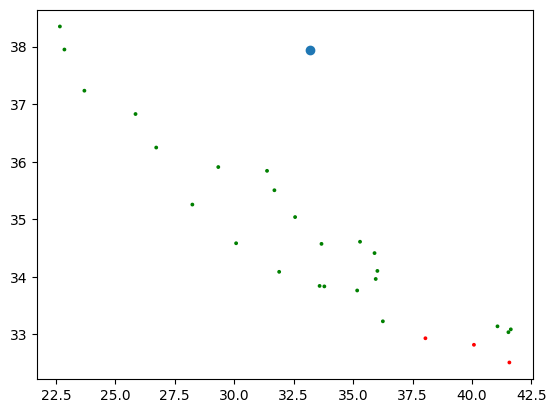

In [49]:
name_plot, code_plot = "سیکل ترکیبی یزد" , "G12"
one_unit_df = Data_selector(Data_selector(df_c).filter_name_code(name_plot, code_plot)).select_peaks(goodness=4)
    
sens_temps = one_unit_df['temp_sens'].values
gens = one_unit_df['generation'].values

X, y = find_points_on_envelope(gens, sens_temps, bin_length=30)

near_envelope_indices = select_envelope_neighbors_indices(X, y, one_unit_df, alpha=2, beta=5)
all_indices.extend(near_envelope_indices)

is_in_area = (one_unit_df['is_good_peak'] == 5).values
X_all = sens_temps
#gens
colors = ['green' if val else 'red' for val in is_in_area]

plt.scatter(X_all,gens,s=3,color=colors)

#plt.plot(X_all,y_pred_all + 2)
#plt.plot(X_all,y_pred_all - 5)
#plt.plot(X_all,y_pred_all)
plt.scatter(X,y)


jonoob esfehan G12<= GX


In [18]:
is_in_area.any()

np.False_